![](../../../images/header.png)

# Galaxy spectra

<h6>Authors : Isa</h6>
<h6>Last Updated : April 3, 2026</h6>


An overview of the electromagnetic spectrum, atomic emission and absorption lines, and the measurement of galaxy spectra with the DESI focal plane, fibers, spectrographs, and CCDs.

In this notebook, we build from the basic physics of light to the practical question of how DESI measures spectra and what those spectra look like for several important DESI source classes. In particular, we will compare:

- **BGS** (Bright Galaxy Survey) galaxies
- **LRGs** (Luminous Red Galaxies)
- **quasars**
- **normal stars**

By the end of this notebook, you should be able to:

- describe where galaxy spectroscopy sits in the electromagnetic spectrum
- explain why atoms produce emission and absorption lines
- distinguish continuum light from spectral-line features
- explain how DESI measures spectra with fibers, spectrographs, and CCDs
- recognize the broad spectral differences among BGS galaxies, LRGs, quasars, and stars


## Preferred Backgrounds


While not necessary, the following background will help:

- basic familiarity with plots
- comfort reading simple equations
- a general idea of what galaxies and stars are
- some experience running Jupyter notebook cells


## Setup

Run the cell below to load the tools used in this notebook.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.figsize"] = (10, 4)

def gaussian(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)



## 1. The electromagnetic spectrum

The light we see around us travels through space in the form of a wave. Some waves of light are shorter or longer than others, and our eyes detect these different **wavelengths** of light as the different colors of the rainbow. The **electromagnetic spectrum** includes all wavelengths of light, from long-wavelength **radio** waves to very short-wavelength **gamma rays**. The below diagram shows the different wavelengths of the electromagnetic spectrum and some of their common applications here on Earth. You'll notice that only a small part of the spectrum corresponds to the **visible light** that our eyes can detect.

<img src="../../../images/EMS_Diagram2.jpg" alt="" width="1000"/>

<h6> Source : <a href="https://mynasadata.larc.nasa.gov/basic-page/electromagnetic-spectrum-diagram"> My NASA Data </a></h6>

Different parts of the electromagnetic spectrum are also important in astronomy as they reveal different physics:

- **Radio:** cold gas, synchrotron emission, jets
- **Infrared:** dust and obscured star formation
- **Visible:** starlight and many strong atomic transitions
- **Ultraviolet:** hot stars and ionized gas
- **X-ray:** accreting black holes and hot plasma

When we **measure a spectrum** in astronomy, we record a broad range of these different wavelengths of light that are emitted by an astronomical object (such as a star or galaxy). Some wavelengths might shine brighter than others due to the physics of the object emitting the light. We can describe how much light that we detect at a specific wavelenth using the notion of **spectral flux density**, that is, the amount of light of a specific wavelenth passing through the surface of our detector. For example, the below graph shows the flux from a incandescent lightbulb that you might find in your house. 

<img src="../../../images/incandescent_light_flux.png" alt="" width="600"/>

<h6> Source : <a href="https://commons.wikimedia.org/wiki/File:Spectral_power_distribution_of_a_25_W_incandescent_light_bulb.png"> Wikimedia Commons </a></h6>

The lightbulb emits more red light than blue light, and it also emits a lot of light at wavelengths longer than 700 nanometers (nm) that our eyes can't see. This is what we call **near-infrared** light. For DESI, the most important region of the electromagnetic spectrum is the **visible to near-infrared**, because many useful features in stars, galaxies, and quasars fall there. 



## 2. Continuum emission, emission lines, and absorption lines

A spectrum is a record of **spectral flux density versus wavelength**.

Most astronomical spectra contain two kinds of information:

### Continuum
The **continuum** is the broad smooth background shape of the spectrum.  
For galaxies, this often comes from the combined light of many stars.  
For quasars, it can be produced by the accretion disk around a black hole.

### Spectral lines
Superimposed on the continuum are narrow or broad features at special wavelengths:

- **absorption lines:** dips in the spectrum where light has been removed
- **emission lines:** peaks in the spectrum where extra light is produced

The continuum gives a broad view of the source, while the spectral lines tell us about specific atoms, ions, and physical conditions.



## 3. Why atoms make discrete lines

Atoms have quantized electron energy levels. Electrons can only jump between specific allowed states.

- When an atom **absorbs** a photon of the right energy, an electron jumps upward and creates an **absorption line**.
- When an electron drops downward and **emits** a photon, it creates an **emission line**.

Each element therefore has its own spectral fingerprint.

Common absorbtion and emission lines include:

- Hydrogen Balmer lines such as H$\alpha$ and H$\beta$
- [O II] and [O III] emission from ionized gas
- Ca H and K absorption from stellar atmospheres
- Mg b absorption from older stellar populations


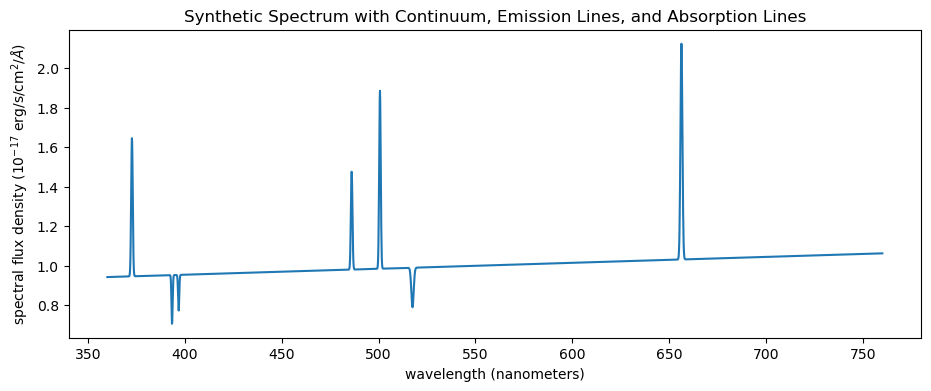

In [12]:

# Synthetic spectrum showing both emission and absorption features

w = np.linspace(3600, 7600, 3000)
continuum = 1.0 + 0.00003 * (w - 5500)
flux = continuum.copy()

# Emission lines
for mu, sig, amp in [(3727, 4, 0.7), (4861, 4, 0.5), (5007, 4, 0.9), (6563, 5, 1.1)]:
    flux += gaussian(w, mu, sig, amp)

# Absorption lines
for mu, sig, amp in [(3934, 3, 0.25), (3968, 3, 0.18), (5175, 6, 0.20)]:
    flux -= gaussian(w, mu, sig, amp)

plt.figure(figsize=(11, 4))
# The factor over 0.1 converts from units of angstroms to nanometers
plt.plot(w*0.1, flux)
plt.xlabel("wavelength (nanometers)")
plt.ylabel(r"spectral flux density ($10^{-17}$ erg/s/cm$^2$/$\AA$)")
plt.title("Synthetic Spectrum with Continuum, Emission Lines, and Absorption Lines")
plt.show()


We can also see emission and absorption lines showing up in real DESI spectra. **Run the below cell to plot a desi spectrum** (you'll notice that the shape of the spectrum is a bit more complicated than our simplified model)

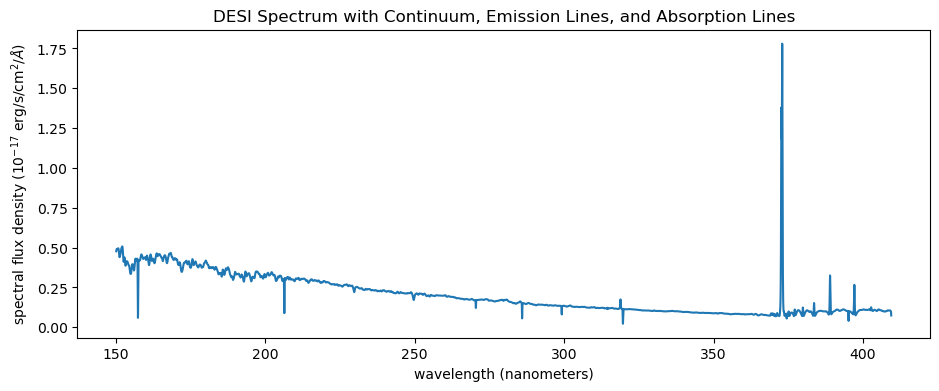

In [13]:
spectrum_fit = Table.read('/global/homes/h/hrincon/code/desihigh/data/target_39633374838524834_redrock_model_data.txt', format = 'ascii.commented_header',header_start = 1,data_start=3,guess=False,fast_reader=False)
plt.figure(figsize=(11, 4))
# The factor over 0.1 converts from units of angstroms to nanometers
plt.plot(spectrum_fit['wave_A']*0.1, spectrum_fit['flux'])
plt.xlabel("wavelength (nanometers)")
plt.ylabel(r"spectral flux density ($10^{-17}$ erg/s/cm$^2$/$\AA$)")
plt.title("DESI Spectrum with Continuum, Emission Lines, and Absorption Lines")
plt.show()


## 5. How DESI measures spectra

DESI turns light from astronomical targets into calibrated spectra through a sequence of steps. These measurements are taken at the Mayall 4-meter Telescope facility in Kitt Peak, Arizona in the United States. Let’s take a tour of the facility and familiarize ourselves with how DESI measures spectra.

<img src="../../../images/Mayall-moon.jpg" alt="" width="600"/>

<h6> The Mayall 4-meter Telescope facility in front of the moon.</a></h6>

<h6> Source : <a href="https://noirlab.edu/public/images/iotw2250a/">M. Hunt/KPNO/NOIRLab/NSF/AURA</a></h6>


### 5.1 Focal plane

Inside the facility, the Mayall Telescope uses a 4-meter (roughly 13-foot) mirror to direct light from the night sky into the DESI instrument. The telescope, mirror, and instrument are shown below.

<img src="../../../images/Mayall-DR1-labled.jpeg" alt="" width="600"/>

<h6> Source : <a href="https://www.desi.lbl.gov/">DESI Collaboration</a></h6>

To measure spectra, DESI first needs to isolate the unique light from each galaxy that it targets. To do so, DESI positions fiber optic cables to capture the light of each galaxy. DESI has 5,000 fiber optic cables, allowing it to detect 5,000 spectra at once. The ends of the cables are arranged inside the DESI instrument on a flat **focal plane.**

<img src="../../../images/DESI_robots.jpg" alt="" width="600"/>

<h6> Source : <a href="https://www.desi.lbl.gov/wp-content/uploads/sites/8/2022/06/DESI_robots.jpg">DESI Collaboration</a></h6>

The above image shows the focal plane, along with a zoom in on some of the fiber cables. The cables are attached to tiny robots that are able to adjust the positions of the fibers. These adjustments (shown below) allow the fibers to point at the precise locations of galaxies in the sky.

<img src="../../../images/DESI_robots_animated.gif" alt="" width="600"/>

<h6> Source : C. Poppett / LBNL</a></h6>



### 5.2 Fiber Cables

Once light from the target galaxies is captured in DESI fiber cables, the light travels through 50 meters (164 feet) of cabling to move from the DESI instrument to a separate room where the spectra will be measured. The path that the cables take is shown in the below diagram of the Mayall telescope, with the cables highlighted in purple.

<img src="../../../images/Mayall_cutaway_04.jpg" alt="" width="600"/>

<h6> Source : <a href="https://photos.lbl.gov/bp/#/folder/4478412/">Lawrence Berkeley National Laboratory</a></h6>

### 5.3 Spectrographs

At this point, the light from each galaxy is composed of many wavelengths. In the visible band, different wavelengths correspond to the different colors of the rainbow. To measure spectra, DESI needs to split the light into its component wavelengths. You may be familiar with a prism, which separates white light into a rainbow. DESI disperses the light of galaxies into spectra using a similar principle.

<img src="../../../images/prism.jpg" alt="" width="600"/>

<h6> Source : <a href="https://commons.wikimedia.org/wiki/File:Prism_flat_rainbow.jpg">Wikimedia Commons</a></h6>

DESI uses a device called a spectrograph to disperse light. DESI has ten spectrographs, each of which take in light from 500 target galaxies at once. The spectrographs, shown below, are kept in a cleanroom to prevent dust from getting on the optics.

<img src="../../../images/spectrographs.jpg" alt="" width="600"/>

<h6> Source : <a href="https://drive.google.com/drive/folders/1xvl-Y3DEVNoMrceU8SVDZjMEvMnUi0pU">DESI Collaboration</a></h6>

### 5.4 CCDs

Once the light is dispersed into its component wavelengths, it next falls onto a type camera called a CCD. The CCDs attached to each spectrograph convert incoming photons into pixel counts, thereby detecting 500 spectra in a single camera image, or 5,000 spectra total across all ten spectrographs.

The below graphics show a CCD image from a real DESI observation along with a cartoon guide that depicts how the dispersed light from the 500 fibers is arranged on the CCD.

<table>
  <tr>
    <td>
      <img src="../../../images/ccd.png" alt="" width="450"/>
    </td>
    <td>
      <img src="../../../images/ccd_cartoon.png" alt="" width="500"/>
    </td>
  </tr>
</table>
<h6> Source : (left) DESI Collboration | (right) D. Steeghs / University of Warwick</a></h6>


### 5.5 Extraction

Lastly, the light from each fiber in the CCD images is processed into a spectrum: flux as a function of wavelength.

So the chain is:

**source on the sky → focal plane → fiber → spectrograph → CCD → extracted spectrum**


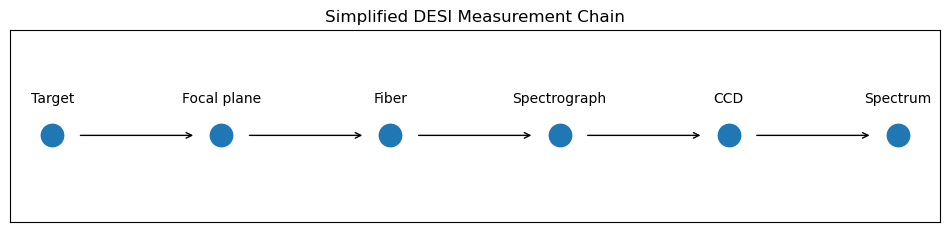

In [5]:

stages = ["Target", "Focal plane", "Fiber", "Spectrograph", "CCD", "Spectrum"]
x = np.arange(len(stages))

plt.figure(figsize=(12, 2.5))
plt.scatter(x, np.zeros_like(x), s=260)

for i, label in enumerate(stages):
    plt.text(i, 0.07, label, ha="center")

for i in range(len(stages) - 1):
    plt.annotate("", xy=(i + 0.85, 0), xytext=(i + 0.15, 0),
                 arrowprops=dict(arrowstyle="->"))

plt.xticks([])
plt.yticks([])
plt.ylim(-0.18, 0.22)
plt.title("Simplified DESI Measurement Chain")
plt.show()



## 6. Why different source classes have different spectra

Spectra differ because different objects are powered by different physical processes.

- A **star** shows the atmosphere of a single photosphere.
- A **galaxy** combines light from many stars, gas clouds, dust, and sometimes a black hole.
- A **quasar** is dominated by radiation from accretion onto a supermassive black hole.

That means different DESI targets can often be recognized directly from the pattern of continuum shape, line widths, and line strengths.



## 7. Spectral breakdown by target class

Below we focus on four broad classes:

1. **BGS galaxies**
2. **LRGs**
3. **quasars**
4. **normal stars**

These are not identical in every individual case, but they have characteristic patterns that are useful for first-pass interpretation.



### 7.1 BGS spectra

**BGS** stands for **Bright Galaxy Survey**. These bright galaxies are relatively closeby in our own cosmic neighborhood, making it easier to detect their light.

Typical spectral properties:

- a visible stellar continuum from the galaxy
- often a mix of **absorption lines** from stars and **emission lines** from gas
- many BGS objects are star-forming or mixed stellar-population galaxies
- common lines can include H$\alpha$, H$\beta$, [O II], [O III], and absorption features such as Ca H and K

A useful mental picture is that BGS spectra often look like **ordinary nearby galaxy spectra**: a continuum from stars plus varying amounts of nebular emission.



### 7.2 LRG spectra

**LRG** stands for **Luminous Red Galaxy**.

Typical spectral properties:

- a **red continuum**
- strong **absorption features**
- weak or absent nebular emission lines
- strong signatures of **old stellar populations**

LRGs are often dominated by older stars, so their spectra usually look smoother and redder than BGS star-forming spectra, with absorption features carrying much of the information.



### 7.3 Quasar spectra

Quasars are powered by accretion onto supermassive black holes.

Typical spectral properties:

- a bright continuum that can often be approximated as a power law
- very strong emission lines
- lines that are often **broad**, because gas near the black hole is moving rapidly

Quasar spectra usually look very different from normal galaxy spectra. Instead of a spectrum dominated by stellar absorption features, they are dominated by a bright active nucleus and strong emission lines.



### 7.4 Normal star spectra

A normal star spectrum is usually the light from a **single stellar photosphere**, not an entire galaxy.

Typical spectral properties:

- a smooth continuum that approximately follows a thermal shape
- many **narrow absorption lines**
- line patterns that depend strongly on temperature, composition, and gravity

Stars are therefore useful as a comparison class: they often show lots of absorption structure but usually do **not** show the mixed galaxy-style pattern of stellar continuum plus nebular emission.


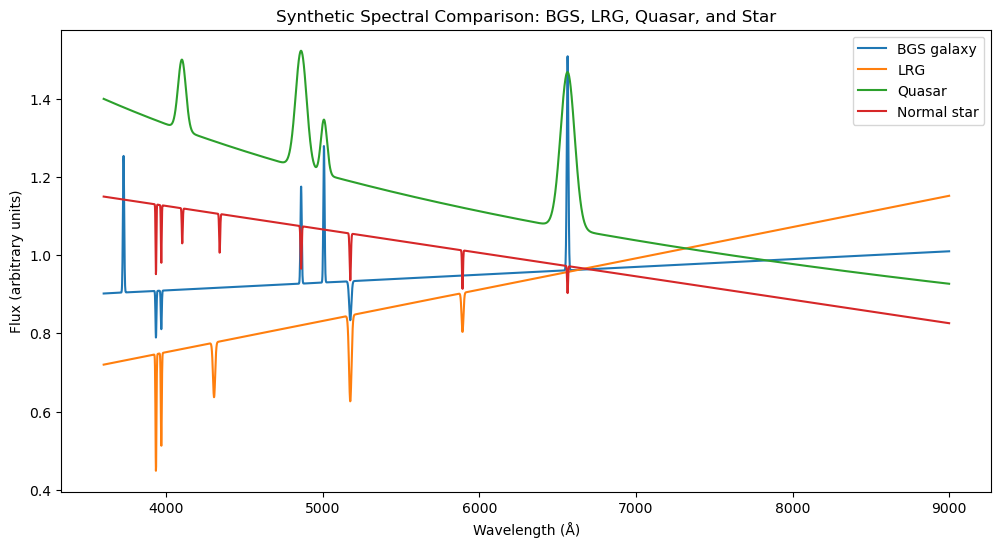

In [6]:

# Synthetic comparison spectra for BGS, LRG, quasar, and a normal star

w = np.linspace(3600, 9000, 4500)

def bgs_spectrum(w):
    f = 0.95 + 0.00002 * (w - 6000)
    # stellar absorption
    f -= gaussian(w, 3934, 3, 0.12)
    f -= gaussian(w, 3968, 3, 0.10)
    f -= gaussian(w, 5175, 7, 0.10)
    # nebular emission
    f += gaussian(w, 3727, 4, 0.35)
    f += gaussian(w, 4861, 4, 0.25)
    f += gaussian(w, 5007, 4, 0.35)
    f += gaussian(w, 6563, 5, 0.55)
    return f

def lrg_spectrum(w):
    f = 0.72 + 0.00008 * (w - 3600)
    f -= gaussian(w, 3934, 3, 0.30)
    f -= gaussian(w, 3968, 3, 0.24)
    f -= gaussian(w, 4305, 7, 0.14)
    f -= gaussian(w, 5175, 8, 0.22)
    f -= gaussian(w, 5892, 6, 0.10)
    return f

def quasar_spectrum(w):
    f = 1.4 * (w / 3600.0) ** (-0.45)
    # broad emission lines
    f += gaussian(w, 4100, 25, 0.18)
    f += gaussian(w, 4861, 35, 0.30)
    f += gaussian(w, 5007, 20, 0.14)
    f += gaussian(w, 6563, 45, 0.40)
    return f

def star_spectrum(w):
    # blackbody-like optical slope approximation for a normal star
    f = 1.15 - 0.00006 * (w - 3600)
    # many narrow absorption lines
    for mu, sig, amp in [
        (3934, 2.5, 0.18), (3968, 2.5, 0.15), (4102, 3.0, 0.09),
        (4341, 3.2, 0.10), (4861, 3.5, 0.11), (5175, 4.0, 0.12),
        (5892, 3.0, 0.10), (6563, 3.0, 0.07)
    ]:
        f -= gaussian(w, mu, sig, amp)
    return f

plt.figure(figsize=(12, 6))
plt.plot(w, bgs_spectrum(w), label="BGS galaxy")
plt.plot(w, lrg_spectrum(w), label="LRG")
plt.plot(w, quasar_spectrum(w), label="Quasar")
plt.plot(w, star_spectrum(w), label="Normal star")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (arbitrary units)")
plt.title("Synthetic Spectral Comparison: BGS, LRG, Quasar, and Star")
plt.legend()
plt.show()



## 8. Reading the comparison plot

Here is a simple way to distinguish the classes:

### BGS
Look for a galaxy-like continuum with a combination of stellar absorption and moderate emission lines.

### LRG
Look for a red continuum and strong absorption features, with very little emission.

### Quasar
Look for a bright non-stellar continuum and strong broad emission lines.

### Star
Look for a smooth stellar continuum with many narrow absorption features and no obvious galaxy-like nebular emission pattern.



## 9. Summary table

| Class | Continuum | Emission lines | Absorption lines | Physical picture |
|---|---|---|---|---|
| BGS | stellar galaxy continuum | often present, sometimes strong | present | bright nearby galaxies with mixed stellar and gas signatures |
| LRG | red continuum | weak or absent | strong | old stellar populations dominate |
| Quasar | bright active continuum | strong, often broad | can be present but not dominant | accreting supermassive black hole |
| Normal star | stellar photosphere continuum | usually weak/absent in this context | many narrow lines | light from a single star |



## 10. Why this matters for DESI

DESI uses spectra to do several things at once:

- determine whether a target is a **galaxy**, **quasar**, or **star**
- measure the **redshift** of galaxies and quasars
- separate different target classes for cosmology analyses
- build a three-dimensional map of large-scale structure

That means the science depends both on the **physics of spectral features** and on the **instrument chain** that measures them.



## 11. Practice questions

1. Why do atoms produce lines only at specific wavelengths?
2. What is the main visual difference between an LRG spectrum and a quasar spectrum?
3. Why might a BGS spectrum show both absorption and emission lines?
4. Why do stellar spectra often contain many narrow absorption features?
5. What role do DESI fibers play in the measurement process?
6. Why is a CCD image not yet the final scientific spectrum?



### Conclusion

You have now worked through a tutorial connecting the physics of light to DESI spectroscopy.

To review:

- the electromagnetic spectrum gives us multiple windows into astrophysical objects
- atomic transitions create emission and absorption lines
- DESI measures spectra using its focal plane, fibers, spectrographs, and CCDs
- BGS, LRG, quasar, and stellar spectra differ because they arise from different physical sources

![](../../../images/footer.png)
